In [4]:
#Q1

In [6]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cm as cm

In [28]:
delta = 0.025
#linspace是生成多少个点,arange表示按照第三个参数step累加
x = np.arange(-3.0,3.0,delta)
y = np.arange(-2.0,2.0,delta)

X,Y = np.meshgrid(x,y)
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X-1) **2 - (Y - 1)**2)
Z = (Z1-Z2)*2

Text(0.5, 1.0, 'Simplest default with labels')

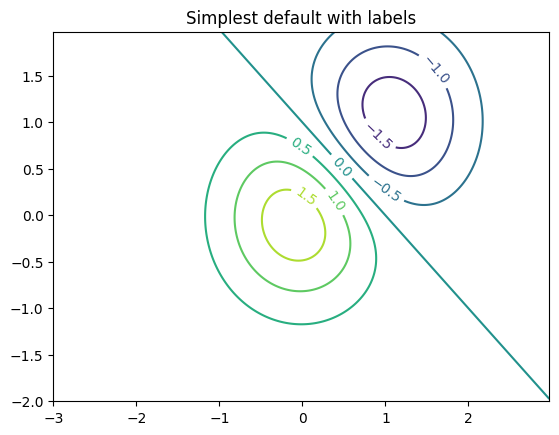

In [34]:
fig,ax = plt.subplots()
CS = ax.contour(X,Y,Z)
#等高线上添加数值标签
ax.clabel(CS,fontsize = 10)
ax.set_title('Simplest default with labels')

Text(0.5, 1.0, 'Single color - negative contours dashed')

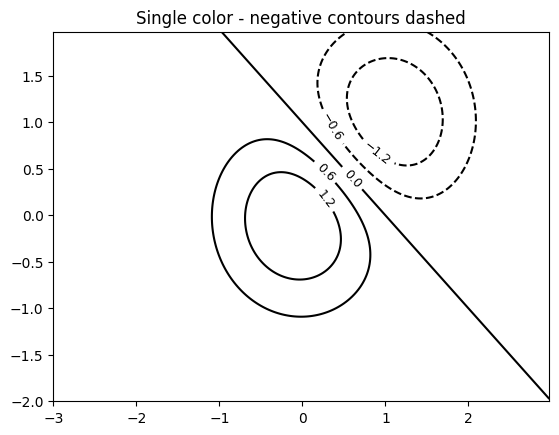

In [36]:
fig,ax = plt.subplots()
#6表示等高线的线束
CS = ax.contour(X,Y,Z,6,colors = 'k')
ax.clabel(CS,fontsize = 9)
ax.set_title('Single color - negative contours dashed')

Text(0.5, 1.0, 'Single color - negative contours solid')

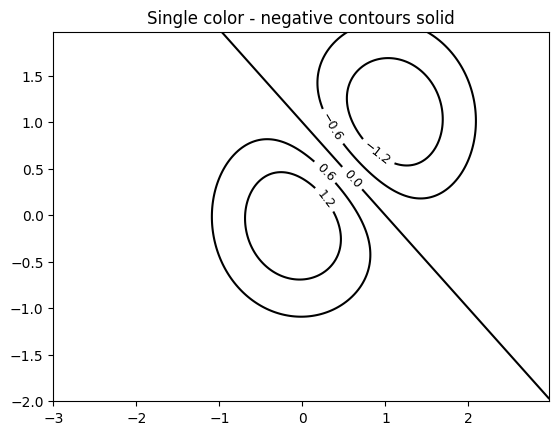

In [44]:
plt.rcParams['contour.negative_linestyle'] = 'solid'
fig,ax = plt.subplots()
CS = ax.contour(X,Y,Z,6,colors = 'k')
ax.clabel(CS,fontsize = 9)
ax.set_title('Single color - negative contours solid')

Text(0.5, 1.0, 'Crazy lines')

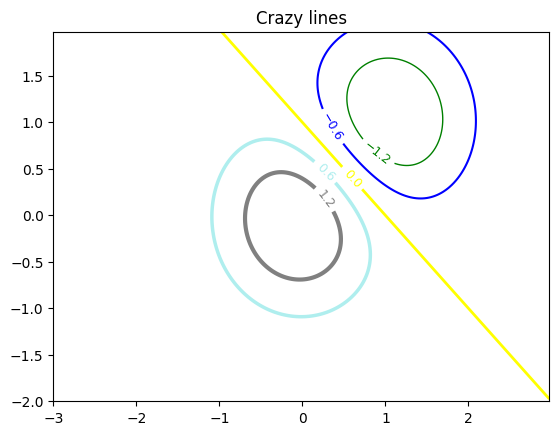

In [50]:
fig,ax = plt.subplots()
CS = ax.contour(X,Y,Z,6,
                linewidths = np.arange(.5,4,.5),
                colors = ('r','green','blue',(1,1,0),'#afeeee','0.5') #不同颜色序列给到不同线
               )
ax.clabel(CS,fontsize = 9)
ax.set_title('Crazy lines')

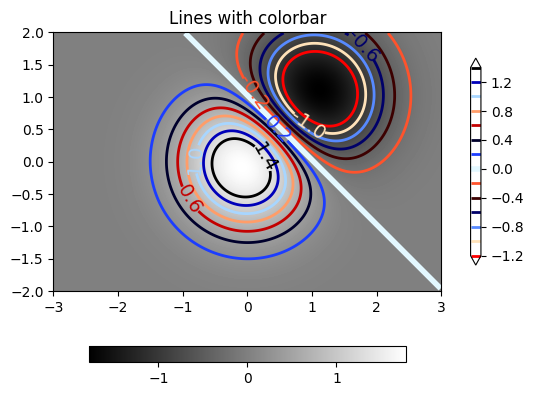

In [116]:
fig,ax = plt.subplots()
#第二个参数为插值图像 = 二线性插值  看起来不是很像素  lower表示[0,0]元素放在左下角
#传入二维数组,Z传入映射为图上的像素的亮度或颜色
im = ax.imshow(Z,interpolation = 'bilinear',origin = 'lower',
               #灰色方案 extent表示这幅图中xy范围
              cmap = cm.gray,extent = (-3,3,-2,2))

levels = np.arange(-1.2,1.6,0.2) #决定在哪些z值上画线
#extend为both表示最小值最大值之外的地方也画线
#extend表示在最低和最高点话轮廓后在用尽头或标记出来超出部分的范围
CS = ax.contour(Z,levels,origin = 'lower',cmap = 'flag',extend = 'both', 
                linewidths = 2,extent=(-3,3,-2,2))

#加粗0的轮廓
#resize表示参数第一个获取了每一条等高线宽度,然后拉伸截断
#resize用法表示如果后者参数大于前者循环重复原数组的元素直到填满 如果更小就从头截取到目标长度
lws = np.resize(CS.get_linewidth(),len(levels))
#索引为6恰好为0线段
lws[6] = 4
CS.set_linewidth(lws)

#只给第二条第四条等高线索引
#[start:stop:step] 省略了stop表示从1到结束,间隔为2
ax.clabel(CS,levels[1::2],
                      #表示了字符串格式,浮点数保留一位小数
                    fmt = '%1.1f',fontsize = 14) 

#给轮廓线绘制彩条
#shrink 控制与默认大小的缩放比例
#shrink效果因为后面的position覆盖了
CB = fig.colorbar(CS,shrink = 0.5) 

ax.set_title('Lines with colorbar')

#图片彩条
#放置在图的底部
CBI = fig.colorbar(im,orientation = 'horizontal' , shrink = 0.8) #

#返回当前主图axes在画布中的位置,结果都在[0,1]中
#getposition 返回边界框对象表示位置
#.bounds 将其拆分长一组数字[a,b,c,d]方便直接读取  作用是将其转换为一行四个数
l,b,w,h = ax.get_position().bounds
#拿到颜色条的位置
ll,bb,ww,hh = CB.ax.get_position().bounds
#调整位置
CB.ax.set_position([ll,b + 0.1*h,ww,h*0.8])

plt.show()

In [118]:
#绘制等高线填充

In [120]:
import matplotlib.pyplot as plt
import numpy as np

In [124]:
delat = 0.025

x = y = np.arange(-3.0,3.01,delta)
X,Y = np.meshgrid(x,y)
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2

nr,nc = Z.shape
#//为向下取整的整数除法 可以理解为数放在竖直的y轴上,向下就是向负方向取整 1.9取整到1 -1.4取整到-2 只要多出来就向下
#这里的数据从-nr开始向下整除6
#这里使用索引得到倒数的索引行和列 位置在右下角设为nan 是无效数据
Z[-nr // 6:, -nc // 6:] = np.nan

#ma是masked array模块 处理掩码数据
#将数组转换为maskedarray 有.mask属性 将会标记哪里数据被屏蔽了
Z = np.ma.array(Z)
#这里区别于上面,将左上角设为掩码值 后续绘图不会显示
Z[:nr // 6,:nc // 6] = np.ma.masked

#掩码用于屏蔽或忽略数据位置 True表示屏幕 False表示保留 绘图或计算时候被标记的部分掩码会被跳过
#掩码值值忽略数据点,重要数据保留
#NaN是浮点数的'非数'覆盖了那个位置,数据已经被替换为无效值

#构造布尔掩码区域
#相撞为圆心半径0.5范围内的所有点
interior = np.sqrt(X**2 + Y**2) < 0.5
#在Z的指定区域构造掩码为True
Z[interior] = np.ma.masked

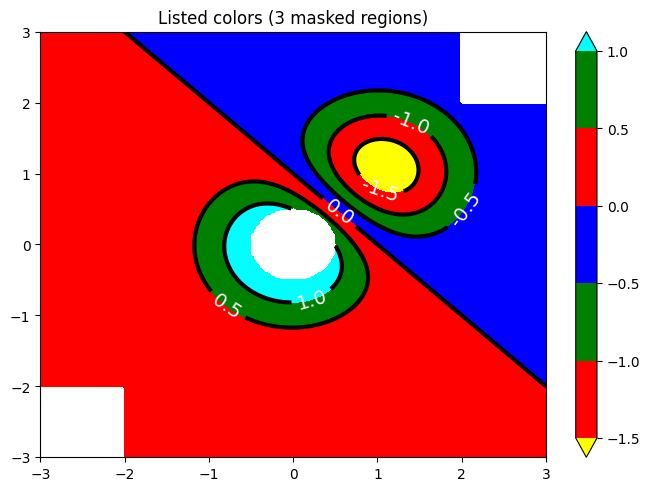

In [140]:
fig,ax2 = plt.subplots(layout = 'constrained')
levels = [-1.5,-1,-0.5,0,0.5,1]
#给CS3返回天色等高线图的类型对象
CS3 = ax2.contourf(X,Y,Z,levels,colors = ('r','g','b'),extend = 'both')
#这里小于levels的地方都填黄色
CS3.cmap.set_under('yellow')
#大于levels的地方都填青色
CS3.cmap.set_over('cyan')

#给CS4返回画线的等高线图对象
CS4 = ax2.contour(X,Y,Z,levels,colors = ('k'),linewidths = (3,))
ax2.set_title('Listed colors (3 masked regions)')
#%2.1f 中2表示最小字段宽度  如果为0.5将会显示 0.5 而不是.5  1表示保留一位小数
#意思是必须保留两个实数字符
ax2.clabel(CS4,fmt = '%2.1f',colors = 'w',fontsize =14)
fig2.colorbar(CS3)

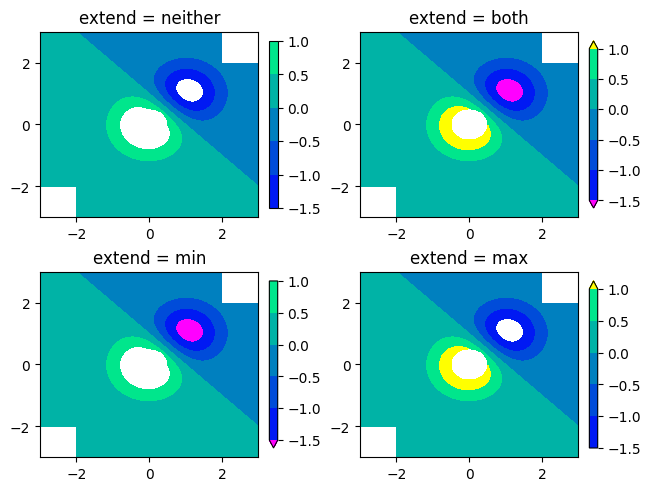

In [150]:
#第一个不在最大最小区域外添加颜色 第三个仅在最小级处添加,第四仅在最大值区域添加
extends = ['neither' , 'both' , 'min' ,'max']
#with_extremes是在cmap对指定低于和高于的值范围配置颜色 extremes表示极值端
cmap = plt.colormaps['winter'].with_extremes(under = 'magenta',over = 'yellow')

#这个layout是一个自动算法,自动调节绘图排版
fig,axs = plt.subplots(2,2,layout = 'constrained')

for ax,extend in zip(axs.flat,extends):
    cs = ax.contourf(X,Y,Z,levels,cmap = cmap,extend = extend)
    fig.colorbar(cs,ax = ax,shrink = 0.9)
    #%s是字符串占位符 会被右侧字符串替代. %d是整数 %f是浮点 %r是任意对象
    ax.set_title('extend = %s' % extend)
    #定位器控制主轴刻度数目尽量为4个
    ax.locator_params(nbins = 4)

plt.show()

In [170]:
x = np.linspace(-np.pi*2,np.pi*2,200)
y_sin = np.sin(x)
y_cos = np.cos(x)

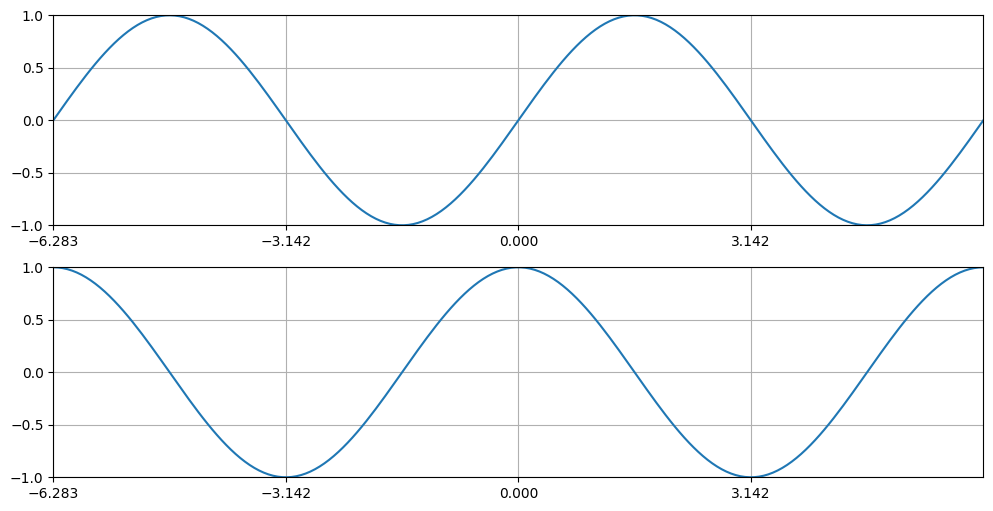

In [215]:
#绘制正余弦函数
fig,axs = plt.subplots(2,1,figsize = (12,6))

#配置x坐标
x_tick = np.arange(-np.pi*2,np.pi*2,np.pi)

for ax,y in zip(axs.flat,[y_sin,y_cos]):
    ax.plot(x,y)
    ax.set_xlim(-np.pi*2,np.pi*2)
    ax.set_ylim(-1,1)
    ax.set_xticks(x_label)
    ax.grid(True)

In [265]:
#将(4,4)转换为极坐标
q3 = np.array([4,4])
r = np.linalg.norm(q3)
theta = np.arctan2(4,4)
theta_deg = np.rad2deg(theta)
theta_deg

print('r is : {%.2f}' %r)
print('deg is : {%.2f}' %theta_deg)

r is : {5.66}
deg is : {45.00}


In [299]:
#计算[4,4]^T的单位向量
q4 = np.array([4,4])
q4_r = np.linalg.norm(q4)
q4_unit = q4 / q4_r
print('q4 vector length is : {%.2f} x {%.2f}' %q4_r %q4_unit)

TypeError: not enough arguments for format string